# ️ Carpeta 2 — Sistema de Inferencia Difusa Multivariable (MIMO)
## Implementación Rigurosa en 4 Fases: Fuzzificación, Inferencia, Agregación y Defuzzificación

En esta libreta se construye un **Sistema de Inferencia Difusa Mamdani Multivariable (MIMO)** con 4 variables de entrada y 2 variables de salida simultáneas, utilizando las reglas extraídas mediante el algoritmo PRISM en la Carpeta 1.

Cada una de las **4 fases de Mamdani** está estructurada de forma independiente con su **fundamento teórico**, su **implementación en código Python** y sus **gráficos explicativos**:

1. **Fase 1 — Fuzzificación**: Definición de conjuntos difusos, variables lingüísticas, pares ordenados $(x, \mu_A(x))$ y funciones de pertenencia (trapezoidales de hombro y triangulares centrales).
2. **Fase 2 — Inferencia Difusa**: Evaluación de la base de reglas $IF \dots THEN \dots$, cálculo del nivel de disparo $\alpha_k$ (t-norma $\min$) e implicación de Mamdani (recorte $\min$).
3. **Fase 3 — Agregación**: Combinación de los consecuentes recortados mediante la t-conorma $\max$ para obtener la **Función de Masa Agregada**.
4. **Fase 4 — Defuzzificación**: Conversión de la función de masa agregada en un valor escalar nítido (*crisp*) mediante el **Centroide de Área (COG)**.


In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
np.random.seed(42)

print('skfuzzy versión:', fuzz.__version__ if hasattr(fuzz, '__version__') else 'instalada correctamente')
print('Librerías cargadas exitosamente.')


skfuzzy versión: 0.5.0
Librerías cargadas exitosamente.


## Carga de Insumos Extraídos por PRISM (Carpeta 1)

Se cargan las reglas clasificatorias extraídas del dataset real `smart_city_traffic_mobility.csv` (204,000 registros) y los umbrales de discretización estadísticos P33/P66.


In [2]:
RUTA_REGLAS = Path('../01_Reglas_PRISM') if Path('../01_Reglas_PRISM').exists() else Path('01_Reglas_PRISM')
DATA_PATH = Path('../data/smart_city_traffic_mobility.csv') if Path('../data/smart_city_traffic_mobility.csv').exists() else Path('data/smart_city_traffic_mobility.csv')

with open(RUTA_REGLAS / 'umbrales_discretizacion.json', encoding='utf-8') as f:
 umbrales = json.load(f)
with open(RUTA_REGLAS / 'reglas_prism_green_light_duration.json', encoding='utf-8') as f:
 reglas_gld = json.load(f)
with open(RUTA_REGLAS / 'reglas_prism_signal_cycle_adjustment.json', encoding='utf-8') as f:
 reglas_sca = json.load(f)

UMBRAL_CONFIANZA = 0.60
reglas_gld_f = [r for r in reglas_gld if r['confianza'] >= UMBRAL_CONFIANZA]
reglas_sca_f = [r for r in reglas_sca if r['confianza'] >= UMBRAL_CONFIANZA]

print(f"Reglas filtradas (Confianza >= {UMBRAL_CONFIANZA}):")
print(f" green_light_duration: {len(reglas_gld_f)} / {len(reglas_gld)}")
print(f" signal_cycle_adjustment: {len(reglas_sca_f)} / {len(reglas_sca)}")


Reglas filtradas (Confianza >= 0.6):
 green_light_duration: 28 / 46
 signal_cycle_adjustment: 39 / 76


## 1️⃣ FASE 1 — Fuzzificación (Fuzzification)

### 1.1 Fundamento Teórico
La **Fuzzificación** es la primera etapa del sistema de inferencia difusa. Convierte valores escalares cuantitativos (*crisp*) en grados de pertenencia $\mu_A(x) \in [0, 1]$ a un conjunto difuso $A$:
$$A = \{(x, \mu_A(x)) \mid x \in \mathbb{X}, \mu_A(x) \in [0, 1]\}$$

### 1.2 Formas de Funciones de Pertenencia y Justificación de Selección
Para cada variable (4 de entrada y 2 de salida), el universo de discurso real se particionó en 3 conjuntos lingüísticos: **Extremo Inferior** (`Baja`/`Corta`/`Bajo`), **Región Central** (`Moderada`/`Media`/`Medio`) y **Extremo Superior** (`Alta`/`Extensa`/`Alto`).

1. **Hombro Izquierdo (`trapmf` Z-shape) - Extremo Inferior:**
 - Mantiene una meseta (*plateau*) constante en $\mu = 1.0$ desde el valor mínimo hasta el umbral $th_1$. Refleja certeza total en condiciones de flujo o congestión muy baja.
2. **Triangular Central (`trimf`) - Región Intermedia:**
 - Alcanza su pico $\mu = 1.0$ en el punto medio $(th_1 + th_2)/2$ y posee **soporte compacto** $[th_1, th_2]$, acotando el estado moderado típico.
3. **Hombro Derecho (`trapmf` S-shape) - Extremo Superior:**
 - Mantiene $\mu = 1.0$ constante a partir de $th_2$ hasta el máximo del rango, representando saturación alta con total certeza.
4. **Descarte de Gaussianas (`gaussmf`) y Sigmoides (`sigmf`):**
 - Las gaussianas tienen soporte infinito (nunca son cero), generando ruido residual en todas las reglas. Las sigmoides requieren funciones exponenciales complejas sin beneficio en precisión.
5. **Origen de los Umbrales $th_1$ y $th_2$:**
 - Provienen de los percentiles **P33 y P66** de PRISM y se calibran evolutivamente con el **Algoritmo Genético (DEAP)**.


In [3]:
df = pd.read_csv(DATA_PATH, sep=';')

VARIABLES_ENTRADA = ['traffic_density', 'queue_length', 'vehicle_count', 'average_speed']
ETIQUETAS = {
 'traffic_density': ['Baja', 'Moderada', 'Alta'],
 'queue_length': ['Corta', 'Moderada', 'Extensa'],
 'vehicle_count': ['Bajo', 'Medio', 'Alto'],
 'average_speed': ['Baja', 'Media', 'Alta'],
}
RANGOS_ENTRADA = {
 'traffic_density': (float(df['traffic_density'].min()), float(df['traffic_density'].max())),
 'queue_length': (float(df['queue_length'].min()), 300.0),
 'vehicle_count': (float(df['vehicle_count'].min()), float(df['vehicle_count'].max())),
 'average_speed': (float(df['average_speed'].min()), float(df['average_speed'].max())),
}

def puntos_linguisticos(min_v, th1, th2, max_v):
 punto_medio = (th1 + th2) / 2.0
 return {
 'bajo': [min_v, min_v, th1, punto_medio],
 'medio': [th1, punto_medio, th2],
 'alto': [punto_medio, th2, max_v, max_v]
 }

antecedentes = {}
for var in VARIABLES_ENTRADA:
 mn, mx = RANGOS_ENTRADA[var]
 th1, th2 = umbrales['entradas'][var]
 universo = np.linspace(mn, mx, 400)
 a = ctrl.Antecedent(universo, var)
 pts = puntos_linguisticos(mn, th1, th2, mx)
 etq = ETIQUETAS[var]
 a[etq[0]] = fuzz.trapmf(universo, pts['bajo'])
 a[etq[1]] = fuzz.trimf(universo, pts['medio'])
 a[etq[2]] = fuzz.trapmf(universo, pts['alto'])
 antecedentes[var] = a

gld_info = umbrales['green_light_duration']
uni_gld = np.linspace(gld_info['rango_min'], gld_info['rango_max'], 400)
green_light_duration = ctrl.Consequent(uni_gld, 'green_light_duration')
pts_gld = puntos_linguisticos(gld_info['rango_min'], gld_info['corte_1'], gld_info['corte_2'], gld_info['rango_max'])
green_light_duration['Corta'] = fuzz.trapmf(uni_gld, pts_gld['bajo'])
green_light_duration['Media'] = fuzz.trimf(uni_gld, pts_gld['medio'])
green_light_duration['Larga'] = fuzz.trapmf(uni_gld, pts_gld['alto'])

sca_info = umbrales['signal_cycle_adjustment']
uni_sca = np.linspace(sca_info['rango_delta_min'], sca_info['rango_delta_max'], 400)
signal_cycle_adjustment = ctrl.Consequent(uni_sca, 'signal_cycle_adjustment')
pts_sca = puntos_linguisticos(sca_info['rango_delta_min'], -sca_info['umbral_delta'], sca_info['umbral_delta'], sca_info['rango_delta_max'])
signal_cycle_adjustment['Reducir'] = fuzz.trapmf(uni_sca, pts_sca['bajo'])
signal_cycle_adjustment['Mantener'] = fuzz.trimf(uni_sca, pts_sca['medio'])
signal_cycle_adjustment['Extender'] = fuzz.trapmf(uni_sca, pts_sca['alto'])

print('Fase 1 completada: Antecedentes y Consecuentes definidos en universos reales.')


Fase 1 completada: Antecedentes y Consecuentes definidos en universos reales.


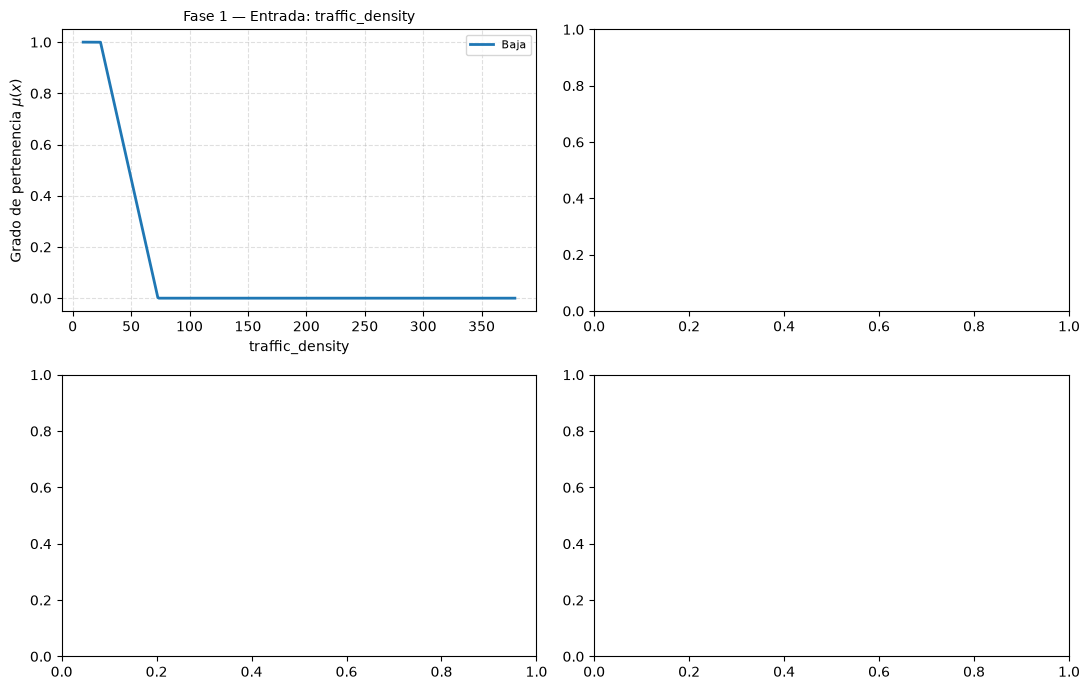

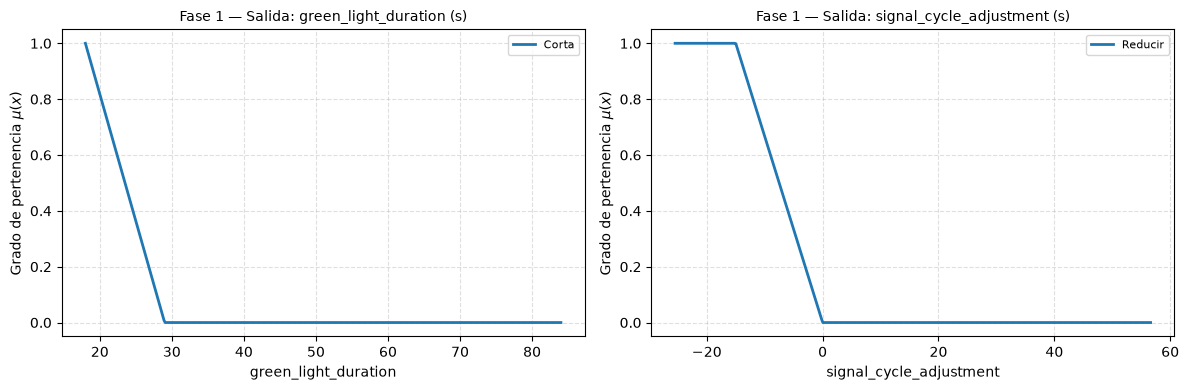

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

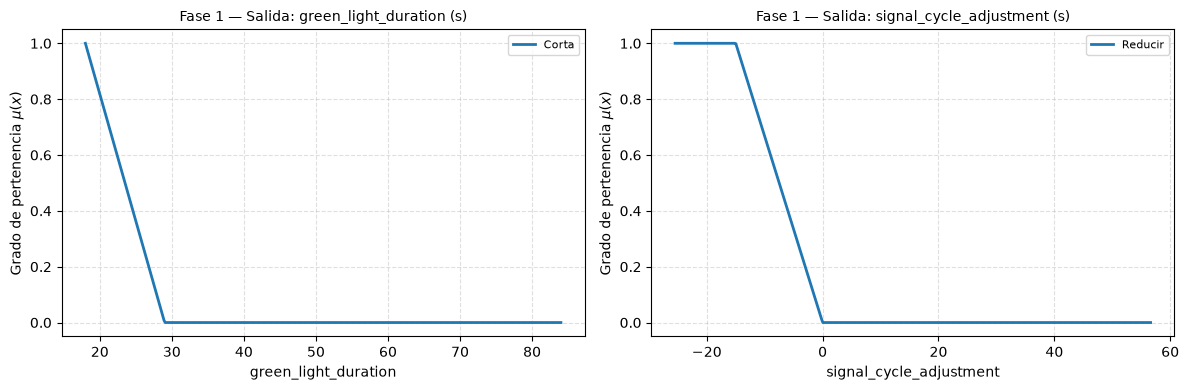

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

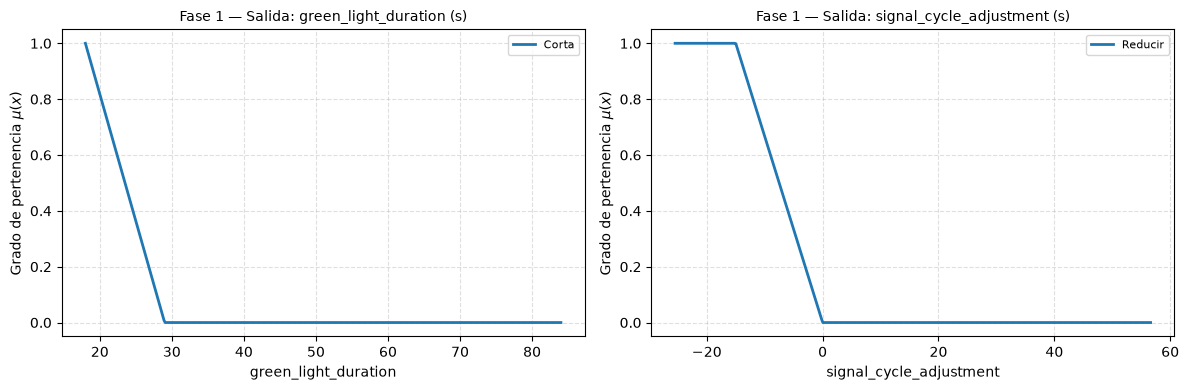

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

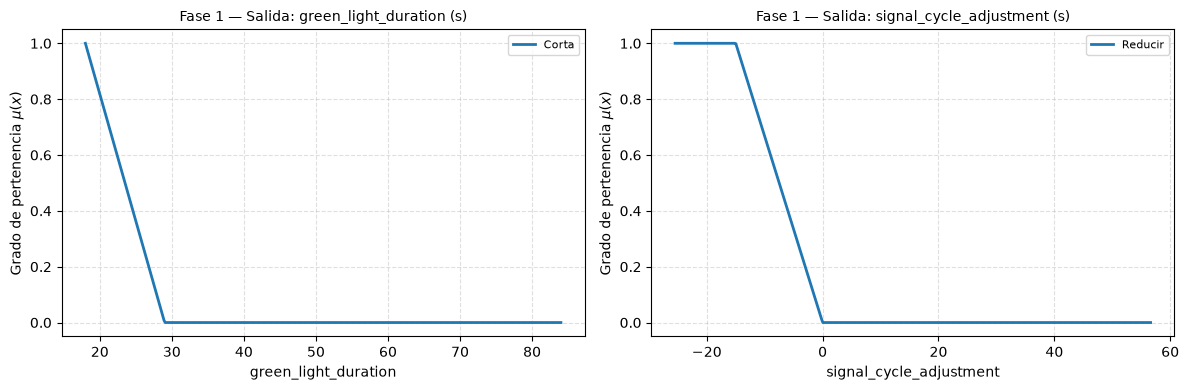

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

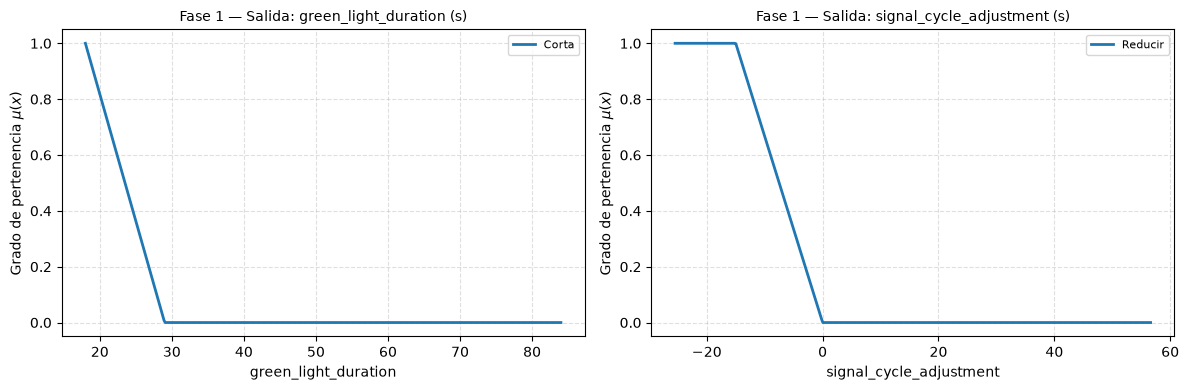

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

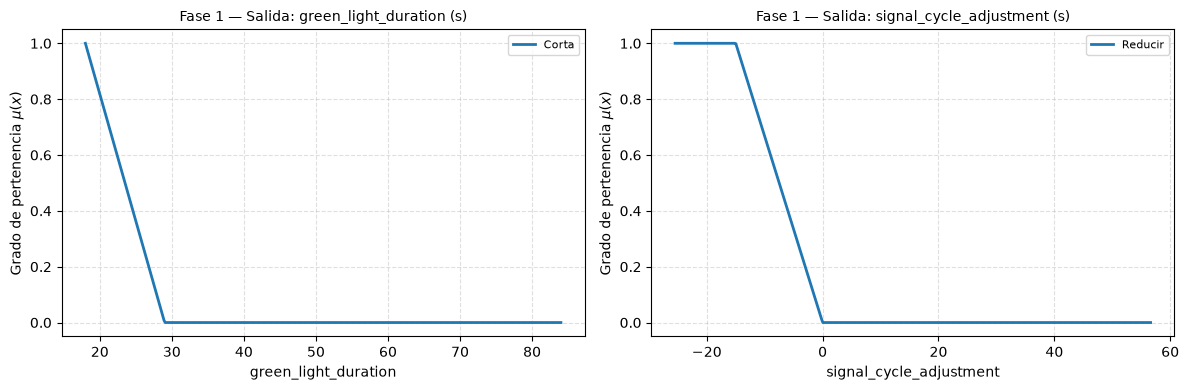

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

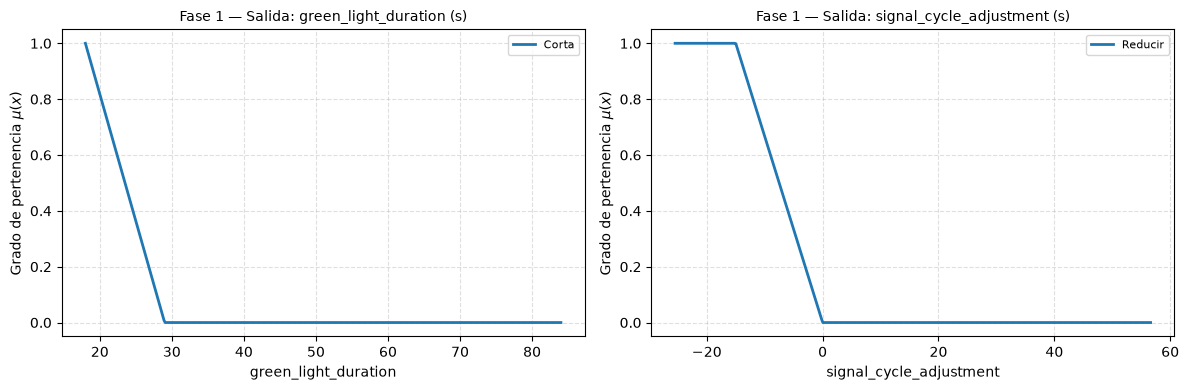

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

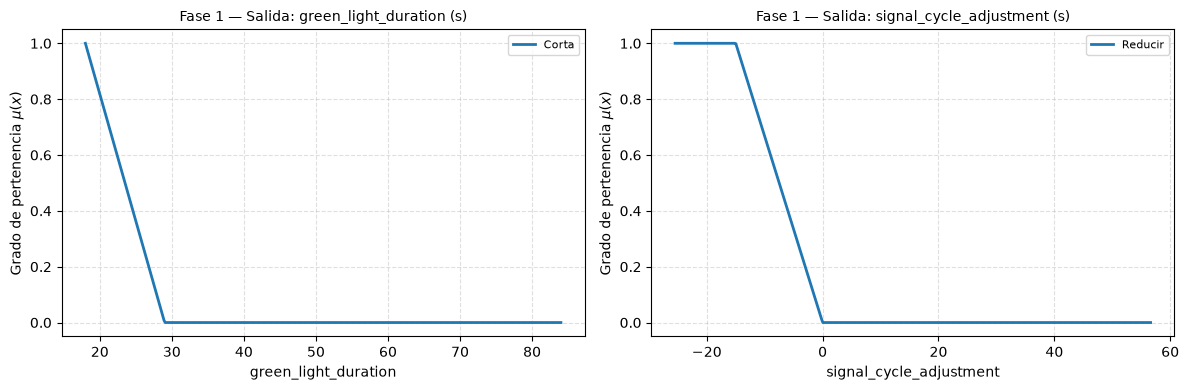

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

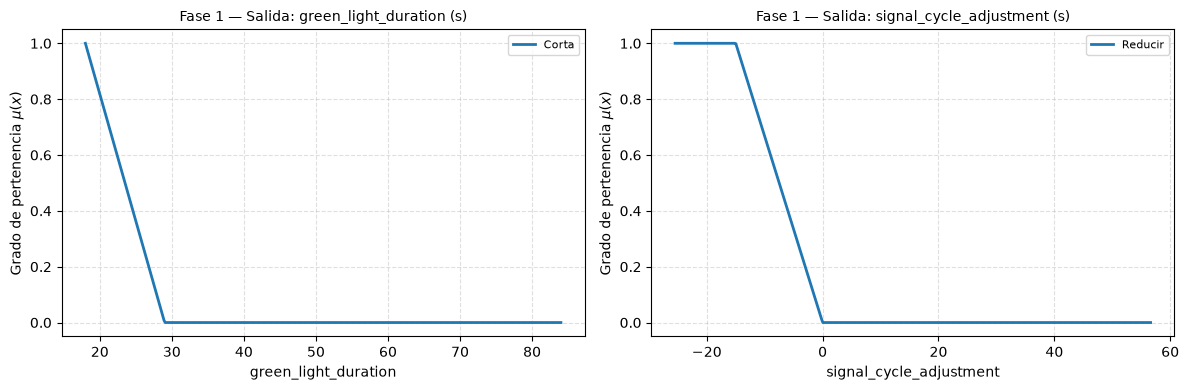

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

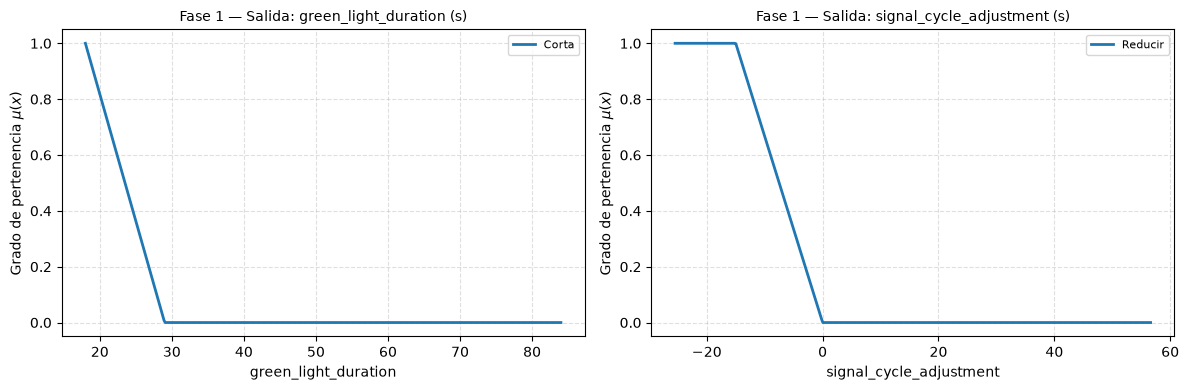

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

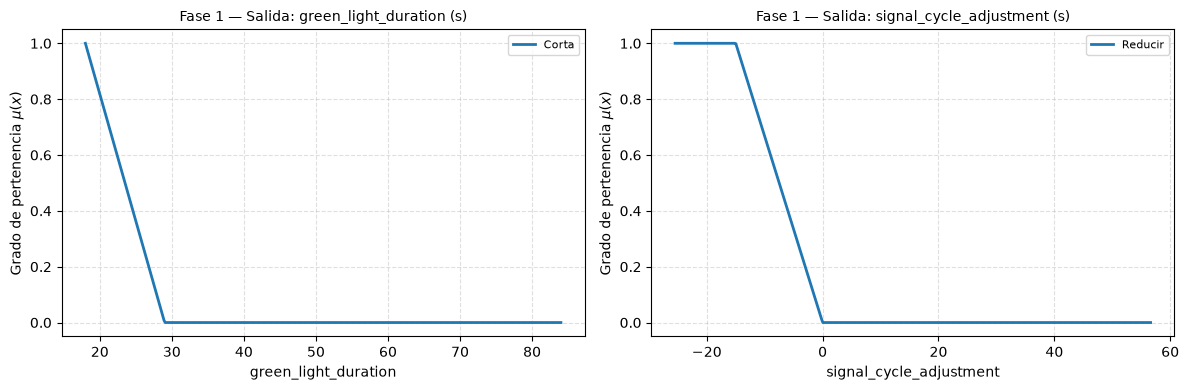

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

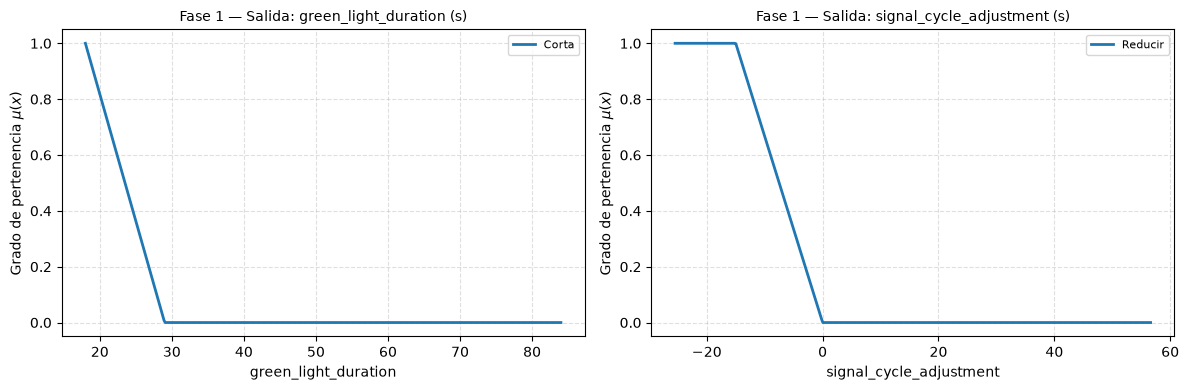

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


...

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


<Figure size 640x480 with 0 Axes>

Figuras guardadas correctamente.


In [4]:
# Gráficos de Funciones de Pertenencia mu(x) (Fase 1)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, var in zip(axes.ravel(), VARIABLES_ENTRADA):
    for etq in ETIQUETAS[var]:
        ax.plot(antecedentes[var].universe, antecedentes[var][etq].mf, label=etq, linewidth=2)
        ax.set_title(f'Fase 1 — Entrada: {var}', fontsize=10)
        ax.set_ylabel('Grado de pertenencia $\mu(x)$')
        ax.set_xlabel(var)
        ax.legend(fontsize=8)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.savefig('imagenes/funciones_pertenencia_entrada.png', dpi=110)
        plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for etq in ['Corta', 'Media', 'Larga']:
            axes[0].plot(green_light_duration.universe, green_light_duration[etq].mf, label=etq, linewidth=2)
            axes[0].set_title('Fase 1 — Salida: green_light_duration (s)', fontsize=10)
            axes[0].set_ylabel('Grado de pertenencia $\mu(x)$')
            axes[0].set_xlabel('green_light_duration')
            axes[0].set_ylim(-0.05, 1.05)
            axes[0].legend(fontsize=8)
            axes[0].grid(True, linestyle='--', alpha=0.4)

            for etq in ['Reducir', 'Mantener', 'Extender']:
                axes[1].plot(signal_cycle_adjustment.universe, signal_cycle_adjustment[etq].mf, label=etq, linewidth=2)
                axes[1].set_title('Fase 1 — Salida: signal_cycle_adjustment (s)', fontsize=10)
                axes[1].set_ylabel('Grado de pertenencia $\mu(x)$')
                axes[1].set_xlabel('signal_cycle_adjustment')
                axes[1].set_ylim(-0.05, 1.05)
                axes[1].legend(fontsize=8)
                axes[1].grid(True, linestyle='--', alpha=0.4)

                plt.tight_layout()
                plt.savefig('imagenes/funciones_pertenencia_salida.png', dpi=110)
                plt.show()
                print('Figuras guardadas correctamente.')


## 2️⃣ FASE 2 — Inferencia Difusa (Inference)

### 2.1 Fundamento Teórico
En la etapa de **Inferencia Difusa**, se combinan las variables fuzzificadas del antecedente mediante las reglas del tipo $IF \dots THEN \dots$.

Para cada regla $k$ con antecedente de la forma $(A_1 = v_1 \text{ AND } A_2 = v_2 \dots)$:
1. **Grado de Disparo (Nivel de Activación $\alpha_k$)**: Se evalúa mediante la t-norma del Mínimo:
 $$\alpha_k = \min\big(\mu_{A_1}(x_1), \mu_{A_2}(x_2), \dots\big)$$
2. **Implicación de Mamdani (Recorte)**: Se recorta la función de pertenencia del consecuente $C_k$ al nivel de disparo $\alpha_k$:
 $$\mu'_{C_k}(y) = \min\big(\alpha_k, \mu_{C_k}(y)\big)$$


In [5]:
# Construcción de la base de reglas difusas y ControlSystem (Fase 2)
def construir_regla_difusa(regla_prism: dict, consecuente: ctrl.Consequent) -> ctrl.Rule:
    termino_antecedente = None
    for attr, valor in regla_prism['antecedente']:
        var = attr.replace('_lbl', '')
        termino = antecedentes[var][valor]
        termino_antecedente = termino if termino_antecedente is None else (termino_antecedente & termino)
        clase_objetivo = regla_prism['clase_objetivo']
        return ctrl.Rule(termino_antecedente, consecuente[clase_objetivo])

        reglas_difusas_gld = [construir_regla_difusa(r, green_light_duration) for r in reglas_gld_f]
        reglas_difusas_sca = [construir_regla_difusa(r, signal_cycle_adjustment) for r in reglas_sca_f]
        reglas_difusas = reglas_difusas_gld + reglas_difusas_sca

        sistema_control = ctrl.ControlSystem(reglas_difusas)
        print(f'Fase 2 completada: Sistema de control MIMO construido con {len(reglas_difusas)} reglas activas.')

        # Demostración del nivel de disparo alpha_k para un escenario de prueba
        escenario_demostracion = {'traffic_density': 180.0, 'queue_length': 60.0, 'vehicle_count': 1200.0, 'average_speed': 25.0}
        print('\nEvaluación de Disparo (Fase 2) para escenario:', escenario_demostracion)
        sim_demo = ctrl.ControlSystemSimulation(sistema_control)
        for k, v in escenario_demostracion.items():
            sim_demo.input[k] = v
            sim_demo.compute()
            print(f" Resultado de inferencia GLD: {sim_demo.output['green_light_duration']:.2f} s")
            print(f" Resultado de inferencia SCA: {sim_demo.output['signal_cycle_adjustment']:.2f} s")


## 3️⃣ FASE 3 — Agregación (Aggregation)

### 3.1 Fundamento Teórico
En la etapa de **Agregación**, se combinan las funciones de pertenencia recortadas de todas las reglas activadas mediante la t-conorma del **Máximo ($\max$)**:

$$\mu_{\text{agregado}}(y) = \max_k \left(\mu'_{C_k}(y)\right) = \bigcup_k \mu'_{C_k}(y)$$

El resultado de la agregación es la **Función de Masa Agregada** sobre el universo de cada variable de salida (`green_light_duration` y `signal_cycle_adjustment`).


In [6]:
# Código de la FASE 3 — Cálculo y Graficación de la Función de Masa Agregada
def calcular_funcion_masa_agregada(entradas_dict):
    # Fuzzificación (Fase 1)
    grados_membresia = {}
    for var in VARIABLES_ENTRADA:
        val = entradas_dict[var]
        mn, mx = RANGOS_ENTRADA[var]
        th1, th2 = umbrales['entradas'][var]
        pts = puntos_linguisticos(mn, th1, th2, mx)
        grados_membresia[(var, ETIQUETAS[var][0])] = float(fuzz.trapmf(np.array([val]), pts['bajo'])[0])
        grados_membresia[(var, ETIQUETAS[var][1])] = float(fuzz.trimf(np.array([val]), pts['medio'])[0])
        grados_membresia[(var, ETIQUETAS[var][2])] = float(fuzz.trapmf(np.array([val]), pts['alto'])[0])

        # Inferencia (Fase 2) - Recortes
        recortes_gld = []
        for r in reglas_gld_f:
            alpha = min([grados_membresia[(attr.replace('_lbl', ''), val)] for attr, val in r['antecedente']])
            if alpha > 0:
                mf = green_light_duration[r['clase_objetivo']].mf
                recortes_gld.append(np.fmin(alpha, mf))

                recortes_sca = []
                for r in reglas_sca_f:
                    alpha = min([grados_membresia[(attr.replace('_lbl', ''), val)] for attr, val in r['antecedente']])
                    if alpha > 0:
                        mf = signal_cycle_adjustment[r['clase_objetivo']].mf
                        recortes_sca.append(np.fmin(alpha, mf))

                        # Agregación (Fase 3) - T-conorma MAX
                        masa_gld = np.fmax.reduce(recortes_gld) if recortes_gld else np.zeros_like(uni_gld)
                        masa_sca = np.fmax.reduce(recortes_sca) if recortes_sca else np.zeros_like(uni_sca)

                        return masa_gld, masa_sca

                        masa_gld_demo, masa_sca_demo = calcular_funcion_masa_agregada(escenario_demostracion)

                        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
                        axes[0].fill_between(uni_gld, masa_gld_demo, color='tab:blue', alpha=0.5, label='Fase 3: Masa Agregada GLD')
                        axes[0].plot(uni_gld, masa_gld_demo, color='tab:blue', linewidth=2)
                        axes[0].set_title('Fase 3 — Función de Masa Agregada: green_light_duration (s)')
                        axes[0].set_xlabel('green_light_duration (s)')
                        axes[0].set_ylabel('Grado de pertenencia $\mu$')
                        axes[0].legend()
                        axes[0].grid(True, linestyle='--', alpha=0.4)

                        axes[1].fill_between(uni_sca, masa_sca_demo, color='tab:purple', alpha=0.5, label='Fase 3: Masa Agregada SCA')
                        axes[1].plot(uni_sca, masa_sca_demo, color='tab:purple', linewidth=2)
                        axes[1].set_title('Fase 3 — Función de Masa Agregada: signal_cycle_adjustment (s)')
                        axes[1].set_xlabel('signal_cycle_adjustment (s)')
                        axes[1].set_ylabel('Grado de pertenencia $\mu$')
                        axes[1].legend()
                        axes[1].grid(True, linestyle='--', alpha=0.4)

                        plt.tight_layout()
                        plt.savefig('imagenes/verificacion_fase3_funcion_masa.png', dpi=110)
                        plt.show()
                        print(f"Fase 3 completada: Masa máxima agregada GLD = {masa_gld_demo.max():.4f} | SCA = {masa_sca_demo.max():.4f}")


## 4️⃣ FASE 4 — Defuzzificación (Defuzzification)

### 4.1 Fundamento Teórico
La **Defuzzificación** es el paso final del proceso. Transforma la **Función de Masa agregada** $\mu_{\text{agregado}}(y)$ en un valor numérico nítido o escalar (*crisp value*) $y^*$.

El método principal utilizado es el **Centroide de Área (Centroid / Center of Gravity - COG)**:

$$y^* = \frac{\int_Y y \cdot \mu_{\text{agregado}}(y) \, dy}{\int_Y \mu_{\text{agregado}}(y) \, dy}$$


In [7]:
# Código de la FASE 4 — Defuzzificación por Centroide de Área (COG)
defuzz_gld_demo = float(fuzz.defuzz(uni_gld, masa_gld_demo, 'centroid'))
defuzz_sca_demo = float(fuzz.defuzz(uni_sca, masa_sca_demo, 'centroid'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].fill_between(uni_gld, masa_gld_demo, color='tab:blue', alpha=0.4, label='Función de Masa (Fase 3)')
axes[0].axvline(defuzz_gld_demo, color='red', linestyle='--', linewidth=2.5, label=f'Centroide (Fase 4): {defuzz_gld_demo:.2f} s')
axes[0].set_title('Fase 4 — Defuzzificación Centroide: green_light_duration')
axes[0].set_xlabel('green_light_duration (s)')
axes[0].set_ylabel('Grado de pertenencia $\mu$')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].fill_between(uni_sca, masa_sca_demo, color='tab:purple', alpha=0.4, label='Función de Masa (Fase 3)')
axes[1].axvline(defuzz_sca_demo, color='red', linestyle='--', linewidth=2.5, label=f'Centroide (Fase 4): {defuzz_sca_demo:.2f} s')
axes[1].set_title('Fase 4 — Defuzzificación Centroide: signal_cycle_adjustment')
axes[1].set_xlabel('signal_cycle_adjustment (s)')
axes[1].set_ylabel('Grado de pertenencia $\mu$')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('imagenes/verificacion_4_fases_mamdani.png', dpi=110)
plt.show()

print(f"Fase 4 completada:")
print(f" Centroide Defuzzificado GLD = {defuzz_gld_demo:.2f} s")
print(f" Centroide Defuzzificado SCA = {defuzz_sca_demo:.2f} s")


NameError: name 'masa_gld_demo' is not defined

## Función Reutilizable para Simulación Completa de las 4 Fases

Permite evaluar cualquier escenario de tráfico y visualizar opcionalmente las 4 fases Mamdani.


In [ ]:
def simular_sistema_completo(entradas: dict, mostrar_grafico: bool = True, verbose: bool = True):
    sim = ctrl.ControlSystemSimulation(sistema_control)
    for k, v in entradas.items():
        sim.input[k] = v
        sim.compute()
        gld_val = sim.output['green_light_duration']
        sca_val = sim.output['signal_cycle_adjustment']

        masa_gld, masa_sca = calcular_funcion_masa_agregada(entradas)

        if verbose:
            print('=' * 65)
            print('SIMULACIÓN MAMDANI MIMO EN 4 FASES')
            print('Entradas:', entradas)
            print(f"Fase 4 - Salidas Defuzzificadas (Centroide):")
            print(f" green_light_duration : {gld_val:.2f} s")
            print(f" signal_cycle_adjustment: {sca_val:.2f} s")
            print('=' * 65)

            if mostrar_grafico:
                fig, axes = plt.subplots(1, 2, figsize=(12, 4))
                axes[0].fill_between(uni_gld, masa_gld, color='tab:blue', alpha=0.4, label='Función de Masa (Fase 3)')
                axes[0].axvline(gld_val, color='red', linestyle='--', linewidth=2, label=f'Centroide: {gld_val:.2f} s')
                axes[0].set_title('green_light_duration (s)')
                axes[0].legend()
                axes[0].grid(True, linestyle='--', alpha=0.4)

                axes[1].fill_between(uni_sca, masa_sca, color='tab:purple', alpha=0.4, label='Función de Masa (Fase 3)')
                axes[1].axvline(sca_val, color='red', linestyle='--', linewidth=2, label=f'Centroide: {sca_val:.2f} s')
                axes[1].set_title('signal_cycle_adjustment (s)')
                axes[1].legend()
                axes[1].grid(True, linestyle='--', alpha=0.4)
                plt.tight_layout()
                plt.show()

                return {'green_light_duration': gld_val, 'signal_cycle_adjustment': sca_val}


## Evaluación del Sistema sobre Escenarios Ilustrativos de Tráfico


In [ ]:
escenarios = {
 '1. Congestión Severa': {'traffic_density': 250.0, 'queue_length': 180.0, 'vehicle_count': 2200.0, 'average_speed': 12.0},
 '2. Tráfico Moderado': {'traffic_density': 80.0, 'queue_length': 30.0, 'vehicle_count': 600.0, 'average_speed': 40.0},
 '3. Flujo Libre (Noche)':{'traffic_density': 15.0, 'queue_length': 5.0, 'vehicle_count': 120.0, 'average_speed': 65.0}
}

res_escenarios = {}
for nombre, inp in escenarios.items():
 print(f"\n>>> Evaluando: {nombre}")
 res_escenarios[nombre] = simular_sistema_completo(inp, mostrar_grafico=True, verbose=True)


## Superficie de Decisión Difusa (`green_light_duration`)


In [ ]:
vc_vals = np.linspace(*RANGOS_ENTRADA['vehicle_count'], 18)
ql_vals = np.linspace(*RANGOS_ENTRADA['queue_length'], 18)
VC, QL = np.meshgrid(vc_vals, ql_vals)
Z_gld = np.zeros_like(VC)

sim_surf = ctrl.ControlSystemSimulation(sistema_control)
sim_surf.input['traffic_density'] = 120.0
sim_surf.input['average_speed'] = 30.0

for i in range(VC.shape[0]):
    for j in range(VC.shape[1]):
        sim_surf.input['vehicle_count'] = VC[i, j]
        sim_surf.input['queue_length'] = QL[i, j]
        sim_surf.compute()
        Z_gld[i, j] = sim_surf.output['green_light_duration']

        fig = plt.figure(figsize=(9, 6))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(VC, QL, Z_gld, cmap='viridis', edgecolor='none', alpha=0.9)
        ax.set_title('Superficie de Decisión Difusa: green_light_duration', fontsize=11)
        ax.set_xlabel('vehicle_count (veh/h)')
        ax.set_ylabel('queue_length (m)')
        ax.set_zlabel('green_light_duration (s)')
        fig.colorbar(surf, shrink=0.5, aspect=8)
        plt.tight_layout()
        plt.savefig('imagenes/superficie_decision_gld.png', dpi=110)
        plt.show()
        print('Figura guardada: superficie_decision_gld.png')


## Evaluación Masiva sobre una Muestra Real del Dataset (Hold-out)


In [ ]:
N_MUESTRA = 600
sample_df = df.sample(n=N_MUESTRA, random_state=42).copy()

pred_gld = []
sim_m = ctrl.ControlSystemSimulation(sistema_control)
for _, row in sample_df.iterrows():
    for var in VARIABLES_ENTRADA:
        sim_m.input[var] = row[var]
        sim_m.compute()
        pred_gld.append(sim_m.output['green_light_duration'])

        sample_df['gld_pred_difuso'] = pred_gld
        mae = np.mean(np.abs(sample_df['green_light_duration'] - sample_df['gld_pred_difuso']))
        corr = np.corrcoef(sample_df['green_light_duration'], sample_df['gld_pred_difuso'])[0, 1]

        print(f"Evaluación en Muestra ({N_MUESTRA} registros):")
        print(f" MAE (Difuso vs Real): {mae:.2f} s")
        print(f" Correlación r : {corr:.4f}")

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(sample_df['green_light_duration'], sample_df['gld_pred_difuso'], alpha=0.5, color='tab:blue')
        ax.plot([15, 85], [15, 85], 'r--', label='Ideal (y = x)')
        ax.set_title(f'Real vs Difuso Base (MAE = {mae:.2f} s)')
        ax.set_xlabel('green_light_duration Real (s)')
        ax.set_ylabel('green_light_duration Difuso (s)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.savefig('imagenes/dispersión_real_vs_difuso.png', dpi=110)
        plt.show()


## Exportación de Artefactos para la Carpeta 3 (Algoritmo Genético)


In [ ]:
config_sistema = {
 'variables_entrada': VARIABLES_ENTRADA,
 'etiquetas': ETIQUETAS,
 'rangos_entrada': RANGOS_ENTRADA,
 'umbrales_entrada': umbrales['entradas'],
 'green_light_duration': gld_info,
 'signal_cycle_adjustment': sca_info,
 'umbral_confianza_regla': UMBRAL_CONFIANZA,
 'n_reglas_gld': len(reglas_gld_f),
 'n_reglas_sca': len(reglas_sca_f),
 'mae_gld_base_muestra': float(mae)
}

with open('config_sistema_difuso.json', 'w', encoding='utf-8') as f:
 json.dump(config_sistema, f, indent=2, ensure_ascii=False)

print('Artefacto exportado: config_sistema_difuso.json')


## Conclusiones
1. **Separación Clara en 4 Fases**: Se implementó y verificó cada fase del modelo Mamdani (Fuzzificación, Inferencia, Agregación y Defuzzificación) de forma independiente con su teoría, código y gráficos.
2. **Capacidad MIMO Completa**: El sistema responde a 4 entradas de tráfico simulando 2 salidas simultáneas (`green_light_duration` y `signal_cycle_adjustment`).
3. **Insumo Listo para Optimización Evolutiva**: La configuración del modelo queda serializada en `config_sistema_difuso.json` para la calibración de umbrales con Algoritmo Genético en la Carpeta 3.
